# Dataset Exploration (HAM10000)

Coarse-To-Fine Hierarchy:
- `diagnosis_1` (e.g., Benign / Malignant / Indeterminate)
- `diagnosis_2` (mid-level groups)
- `diagnosis_3` (final class-label for training)


In [1]:
from pathlib import Path
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

random.seed(42)

In [2]:
PROJECT_ROOT = Path("..").resolve()
DATASET_DIR = PROJECT_ROOT / "data" / "raw"
META_PATH = DATASET_DIR / "metadata.csv"
metadata = pd.read_csv(META_PATH)

display_cols = [
    "isic_id",
    "lesion_id",
    "diagnosis_1",
    "diagnosis_2",
    "diagnosis_3",
    "age_approx",
    "sex",
    "anatom_site_general",
    "melanocytic",
]

styled = (
    metadata[display_cols]
    .head()
    .style
    .set_properties(**{"text-align": "left"})
    .set_table_styles([
        {"selector": "th", "props": [("text-align", "left")]}
    ])
)
display(styled)


,isic_id,lesion_id,diagnosis_1,diagnosis_2,diagnosis_3,age_approx,sex,anatom_site_general,melanocytic
0,ISIC_0024306,IL_7252831,Benign,Benign melanocytic proliferations,Nevus,45.000000,male,nan,True
1,ISIC_0024307,IL_6125741,Benign,Benign melanocytic proliferations,Nevus,50.000000,male,lower extremity,True
2,ISIC_0024308,IL_3692653,Benign,Benign melanocytic proliferations,Nevus,55.000000,female,nan,True
3,ISIC_0024309,IL_0959663,Benign,Benign melanocytic proliferations,Nevus,40.000000,male,nan,True
4,ISIC_0024310,IL_8194852,Malignant,Malignant melanocytic proliferations (Melanoma),"Melanoma, NOS",60.000000,male,anterior torso,True


## Label Completeness Check

Verify that every image has a label for all three diagnosis levels.

In [12]:
diag_cols = ["diagnosis_1", "diagnosis_2", "diagnosis_3"]

completeness_data = []
for col in diag_cols:
    total = len(metadata)
    non_null = metadata[col].notna().sum()
    null = metadata[col].isna().sum()
    pct = non_null / total * 100
    completeness_data.append({
        "Column": col,
        "Total": total,
        "Non-Null": non_null,
        "Null": null,
        "Complete (%)": f"{pct:.1f}",
    })

completeness_df = pd.DataFrame(completeness_data)

styled = (
    completeness_df
    .style
    .set_properties(**{"text-align": "center"})
    .set_table_styles([
        {"selector": "th", "props": [("text-align", "left")]}
    ])
    .hide(axis="index")
)
display(styled)

all_complete = all(metadata[col].notna().all() for col in diag_cols)
if all_complete:
    print("\nEvery image has a label for all three diagnosis levels.")
else:
    for col in diag_cols:
        n_missing = metadata[col].isna().sum()
        if n_missing > 0:
            print(f"{col}: {n_missing} images have no valid label.")


Column,Total,Non-Null,Null,Complete (%)
diagnosis_1,11720,11720,0,100.0
diagnosis_2,11720,11720,0,100.0
diagnosis_3,11720,11540,180,98.5


diagnosis_3: 180 images have no valid label.


## Key Dataset Statistics

In [4]:
imgs_per_lesion = metadata.groupby("lesion_id").size()

stats_data = [
    {"Metric": "Total images",                 "Value": len(metadata)},
    {"Metric": "Total unique lesions",          "Value": metadata["lesion_id"].nunique()},
    {"Metric": "Avg. images per lesion",        "Value": f"{imgs_per_lesion.mean():.2f}"},
    {"Metric": "Min images per lesion",         "Value": imgs_per_lesion.min()},
    {"Metric": "Max images per lesion",         "Value": imgs_per_lesion.max()},
    {"Metric": "Median images per lesion",      "Value": f"{imgs_per_lesion.median():.1f}"},
    {"Metric": "Unique diagnosis_1 classes",    "Value": metadata["diagnosis_1"].nunique()},
    {"Metric": "Unique diagnosis_2 classes",    "Value": metadata["diagnosis_2"].nunique()},
    {"Metric": "Unique diagnosis_3 classes",    "Value": metadata["diagnosis_3"].nunique()},
]

stats_df = pd.DataFrame(stats_data)

styled = (
    stats_df
    .style
    .set_properties(**{"text-align": "left"})
    .set_table_styles([
        {"selector": "th", "props": [("text-align", "left")]}
    ])
    .hide(axis="index")
)
display(styled)


Metric,Value
Total images,11720
Total unique lesions,8838
Avg. images per lesion,1.33
Min images per lesion,1
Max images per lesion,6
Median images per lesion,1.0
Unique diagnosis_1 classes,3
Unique diagnosis_2 classes,8
Unique diagnosis_3 classes,7


## Class Distribution Bar Charts

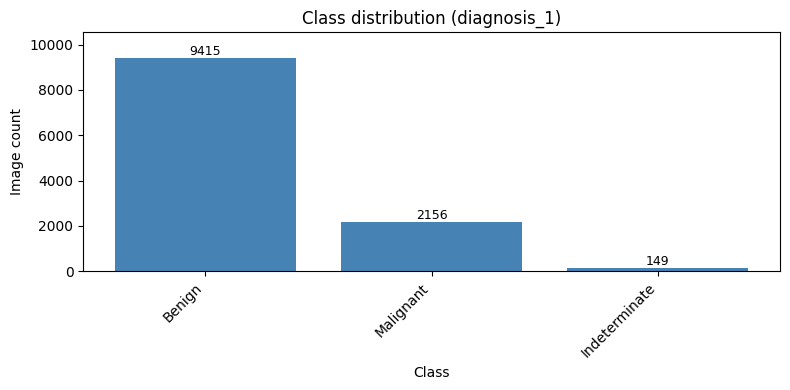

In [15]:
# Bar chart: distribution of diagnosis_1 classes
counts = metadata["diagnosis_1"].value_counts().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(range(len(counts)), counts.values, color="steelblue")
ax.set_xticks(range(len(counts)))
ax.set_xticklabels(counts.index, rotation=45, ha="right")
ax.set_title("Class distribution (diagnosis_1)")
ax.set_ylabel("Image count")
ax.set_xlabel("Class")
ax.set_ylim(0, counts.max() * 1.12)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            str(val), ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()


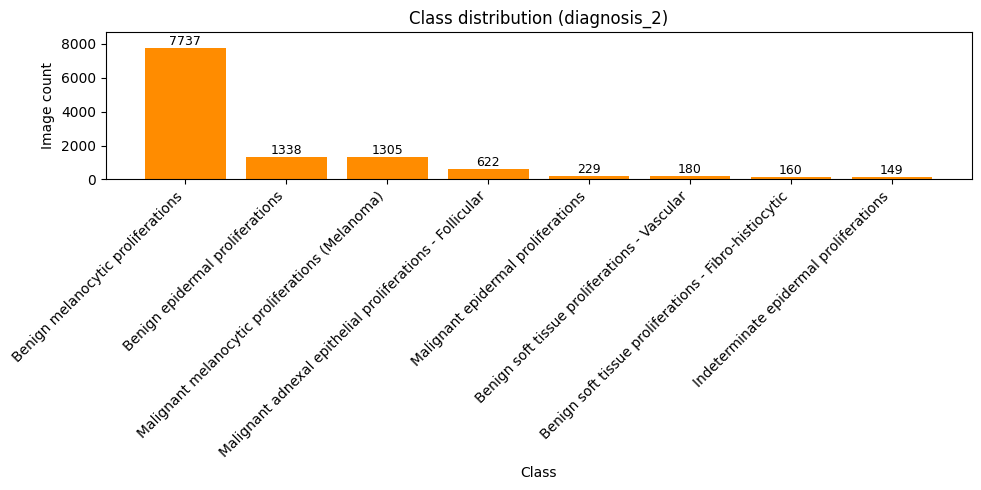

In [13]:
# Bar chart: distribution of diagnosis_2 classes
counts = metadata["diagnosis_2"].value_counts().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(range(len(counts)), counts.values, color="darkorange")
ax.set_xticks(range(len(counts)))
ax.set_xticklabels(counts.index, rotation=45, ha="right")
ax.set_title("Class distribution (diagnosis_2)")
ax.set_ylabel("Image count")
ax.set_xlabel("Class")
ax.set_ylim(0, counts.max() * 1.12)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            str(val), ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()


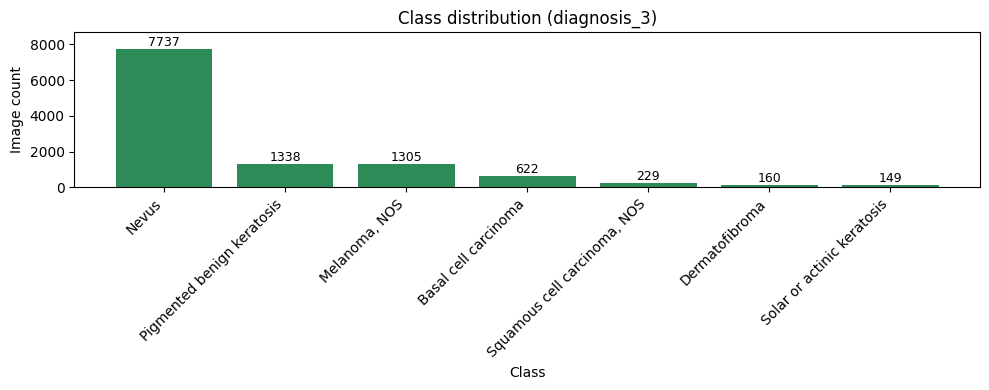

In [14]:
# Bar chart: distribution of diagnosis_3 classes
counts = metadata["diagnosis_3"].value_counts().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(range(len(counts)), counts.values, color="seagreen")
ax.set_xticks(range(len(counts)))
ax.set_xticklabels(counts.index, rotation=45, ha="right")
ax.set_title("Class distribution (diagnosis_3)")
ax.set_ylabel("Image count")
ax.set_xlabel("Class")
ax.set_ylim(0, counts.max() * 1.12)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            str(val), ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()


## Sample Images: All Pictures of One Lesion per Diagnosis

For each `diagnosis_3` class we randomly pick **one lesion** and show **all** its images.

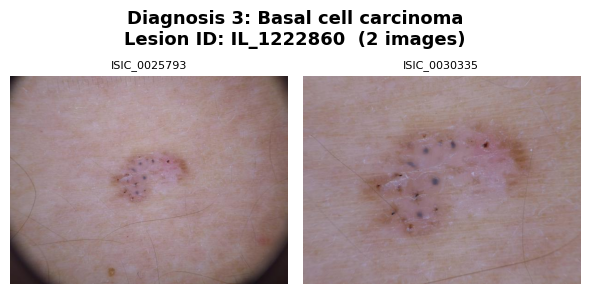

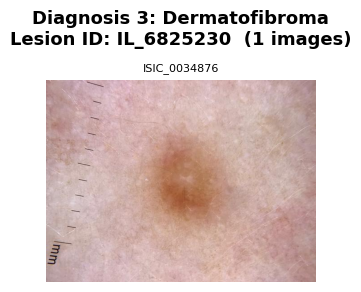

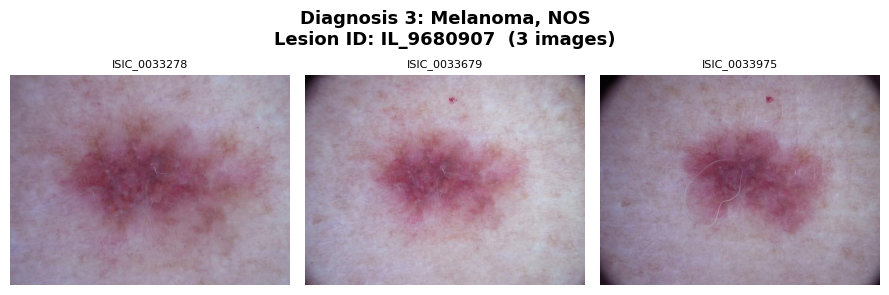

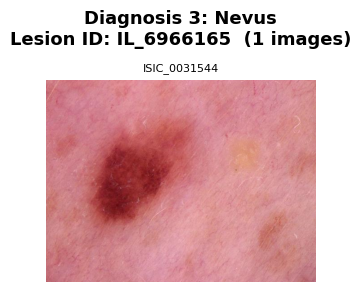

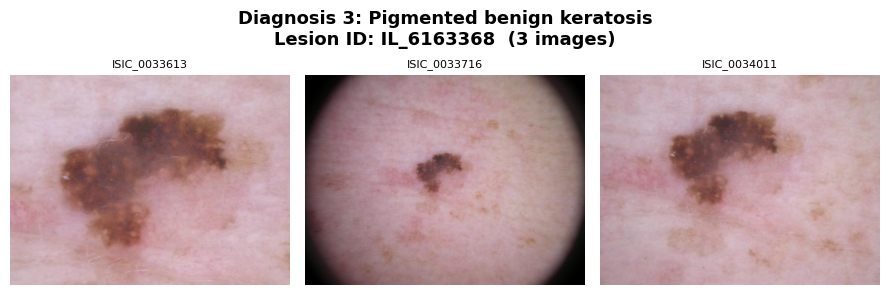

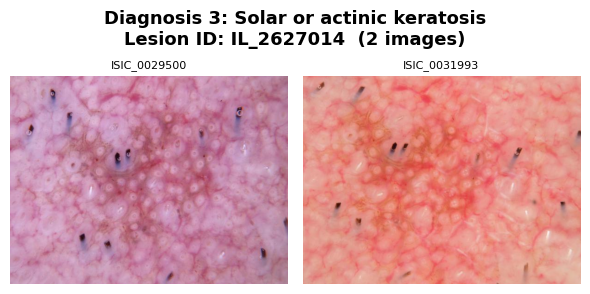

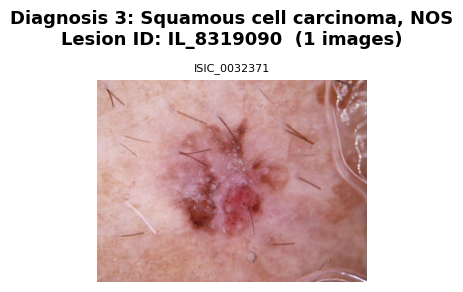

In [16]:
label_col = "diagnosis_3"

for cls in sorted(metadata[label_col].dropna().unique()):
    subset = metadata[metadata[label_col] == cls]
    # Pick one random lesion
    lesion = subset["lesion_id"].drop_duplicates().sample(1, random_state=42).iloc[0]
    lesion_imgs = subset[subset["lesion_id"] == lesion]

    n = len(lesion_imgs)
    cols = min(n, 6)
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
    if n == 1:
        axes = np.array([axes])
    axes = np.atleast_1d(axes).flatten()

    fig.suptitle(
        f"Diagnosis 3: {cls}\nLesion ID: {lesion}  ({n} images)",
        fontsize=13, fontweight="bold"
    )

    for ax, (_, row) in zip(axes, lesion_imgs.iterrows()):
        img_path = DATASET_DIR / f"{row['isic_id']}.jpg"
        if img_path.exists():
            img = plt.imread(img_path)
            ax.imshow(img)
        ax.set_title(row["isic_id"], fontsize=8)
        ax.axis("off")

    for ax in axes[n:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()
